
МОДЕЛЬ ИСТОРИЧЕСКОЙ ДИНАМИКИ С МНОЖЕСТВЕННЫМИ ДОБАВКАМИ

▶ ИСТОРИЧЕСКИЕ СЦЕНАРИИ С ДОБАВКАМИ:


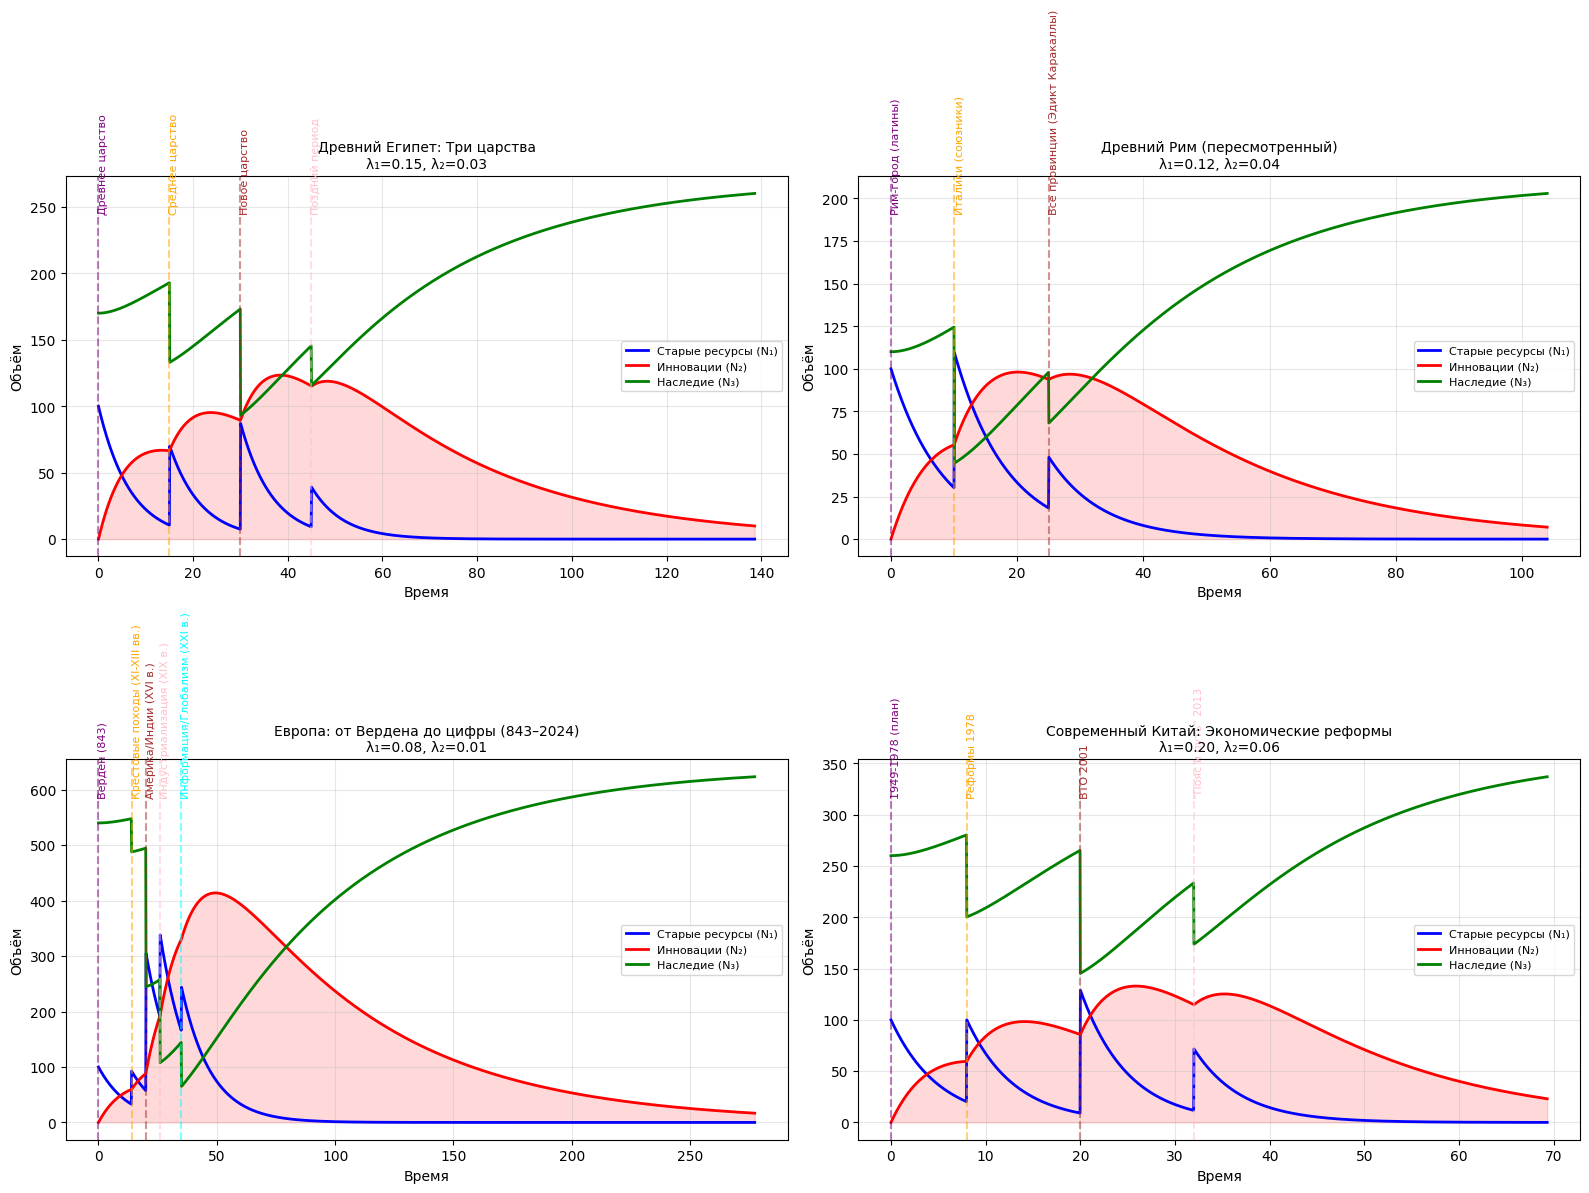


▶ ДРЕВНИЙ ЕГИПЕТ: ТРИ ЦАРСТВА


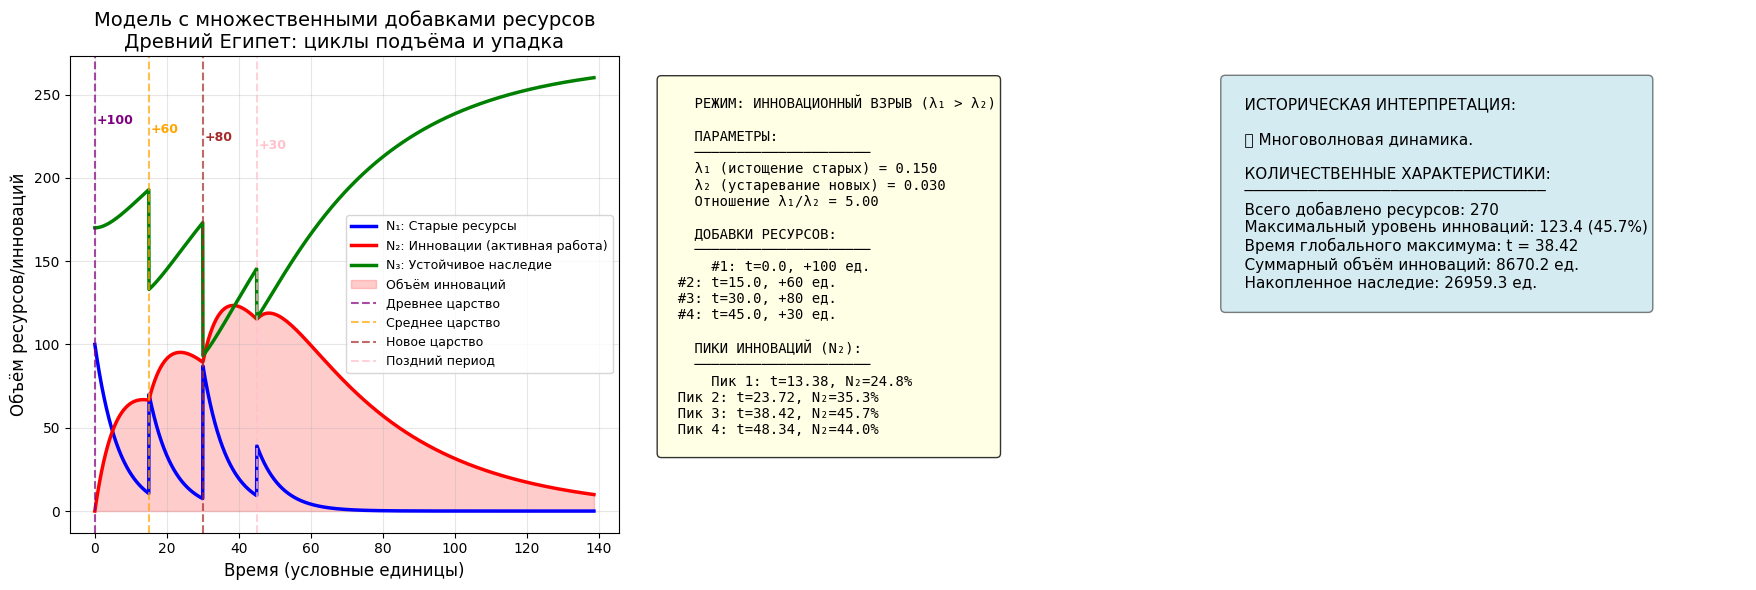


▶ ДРЕВНИЙ РИМ: ПОЭТАПНОЕ РАСШИРЕНИЕ ГРАЖДАНСТВА (ПЕРЕСМОТРЕННАЯ МОДЕЛЬ)
   (Рим-город → Италики → Все провинции с низкой эффективностью)


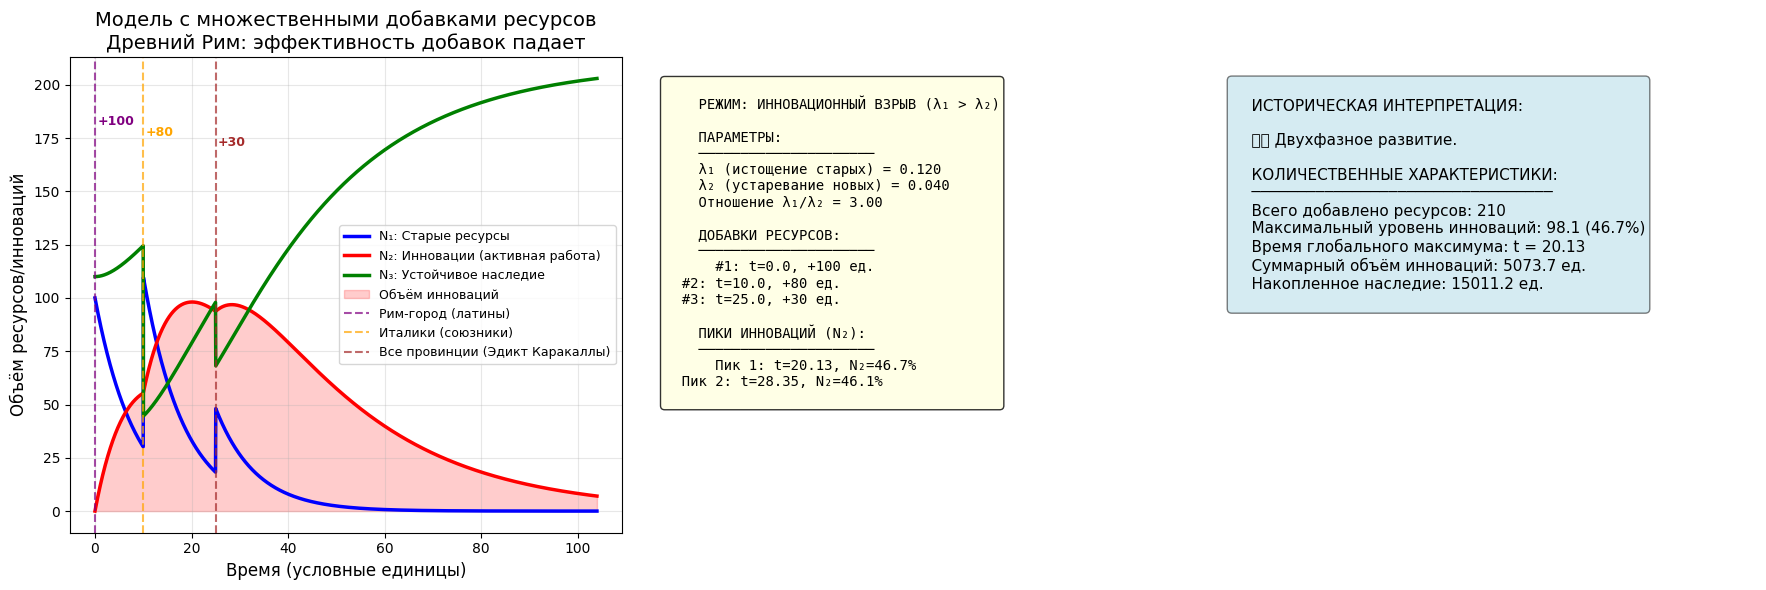


▶ ЕВРОПА: ОТ ВЕРДЕНСКОГО ДОГОВОРА (843) ДО НАШИХ ДНЕЙ
   Единый 1200-летний цикл развития


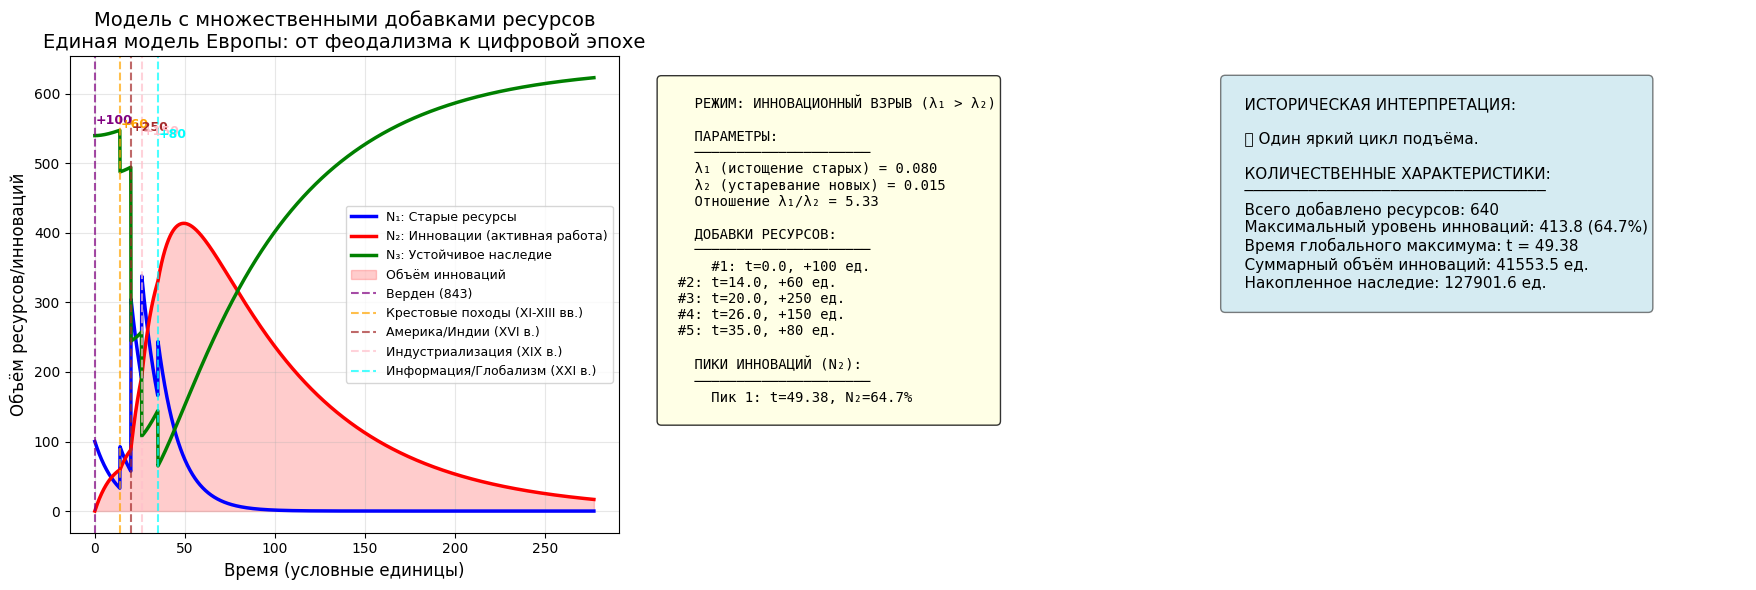


▶ СОВРЕМЕННЫЙ КИТАЙ: ЭКОНОМИЧЕСКИЕ РЕФОРМЫ


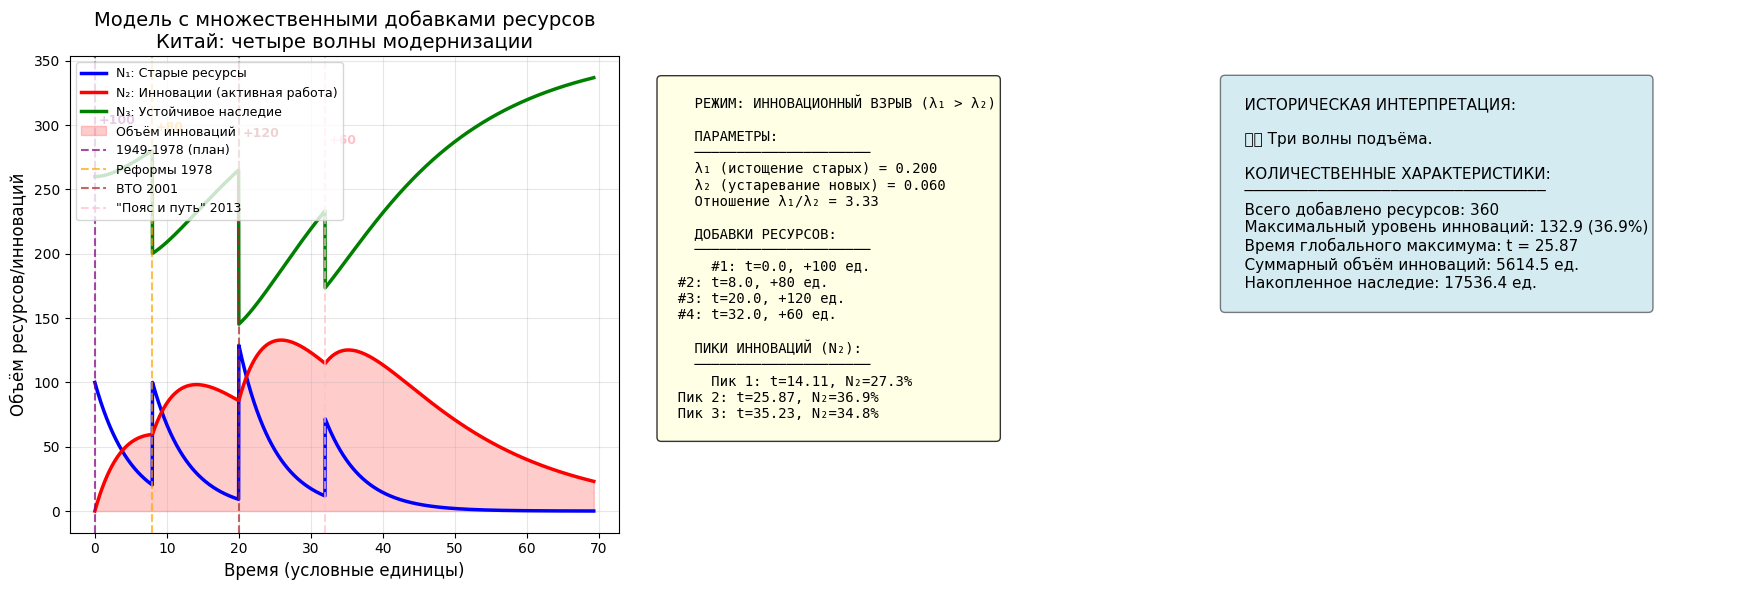


ИНТЕРАКТИВНЫЙ РЕЖИМ (Jupyter):
Раскомментируйте строку ниже для запуска с ползунками.


interactive(children=(FloatLogSlider(value=0.12, description='λ₁ (истощение старых)', max=0.5, min=-2.0, step=…

In [2]:
# =============================================================================
# БЛОК 1: ИМПОРТ БИБЛИОТЕК
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatLogSlider, FloatSlider, IntSlider, fixed
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# БЛОК 2: УНИВЕРСАЛЬНАЯ ФУНКЦИЯ ДЛЯ ПЛОЩАДИ
# =============================================================================
def compute_area(y, x):
    """Вычисляет площадь под кривой методом трапеций."""
    return np.sum((x[1:] - x[:-1]) * (y[1:] + y[:-1]) / 2)

# =============================================================================
# БЛОК 3: ЯДРО МОДЕЛИ С МНОЖЕСТВЕННЫМИ ДОБАВКАМИ
# =============================================================================
def historical_dynamics_with_injections(
    lambda_old,       # скорость исчерпания старых ресурсов
    lambda_new,       # скорость устаревания инноваций
    base_N0=100,      # начальная порция ресурсов
    injections=None,  # список кортежей (время, объём_добавки)
    t_max=None,
    num_points=2000
):
    """
    Модель исторической динамики с множественными добавками ресурсов.

    injections: список [(t1, N01), (t2, N02), ...]
        - tᵢ: момент времени, когда поступает новая порция
        - N0ᵢ: объём добавляемых ресурсов
    """

    if injections is None:
        injections = [(0, base_N0)]

    # Автоматический подбор t_max
    if t_max is None:
        min_lambda = min(lambda_old, lambda_new) if min(lambda_old, lambda_new) > 0 else 0.001
        # Базовое время для самого медленного процесса
        base_time = 6 * np.log(2) / min_lambda
        # Добавляем время на все инъекции + запас
        last_injection_time = max([t for t, _ in injections]) if injections else 0
        t_max = max(base_time, last_injection_time + 3 * np.log(2) / min_lambda)

    t = np.linspace(0, t_max, num_points)

    # Инициализируем массивы
    N1 = np.zeros_like(t)
    N2 = np.zeros_like(t)
    N3 = np.zeros_like(t)

    # Для каждой добавки считаем её вклад
    for t_inj, N0_inj in injections:
        # Маска: время >= момента добавки
        mask = t >= t_inj
        tau = t[mask] - t_inj  # локальное время с момента добавки

        # Вклад в старые ресурсы (экспоненциальное истощение)
        N1_inj = N0_inj * np.exp(-lambda_old * tau)
        N1[mask] += N1_inj

        # Вклад в инновации (формула Бейтмана для каждой добавки)
        if abs(lambda_old - lambda_new) < 1e-12:
            N2_inj = N0_inj * lambda_old * tau * np.exp(-lambda_old * tau)
        else:
            N2_inj = N0_inj * (lambda_old / (lambda_new - lambda_old)) * (
                np.exp(-lambda_old * tau) - np.exp(-lambda_new * tau)
            )
        N2[mask] += N2_inj

    # Устойчивое наследие (закон сохранения массы для каждой точки времени)
    total_injected = sum([N0_inj for _, N0_inj in injections])
    N3 = total_injected - N1 - N2
    N3 = np.maximum(N3, 0)

    return t, N1, N2, N3

# =============================================================================
# БЛОК 4: ВИЗУАЛИЗАЦИЯ С ИСТОРИЧЕСКОЙ ИНТЕРПРЕТАЦИЕЙ
# =============================================================================
def plot_history_with_injections(
    lambda_old, lambda_new,
    injections=None,
    labels=None,
    log_scale=False,
    title_addon=""
):
    """
    Визуализация исторической динамики с несколькими добавками ресурсов.
    """

    if injections is None:
        injections = [(0, 100)]
    if labels is None:
        labels = [f"Добавка {i+1}: t={t:.1f}, объём={N0:.0f}" for i, (t, N0) in enumerate(injections)]

    t, N1, N2, N3 = historical_dynamics_with_injections(
        lambda_old, lambda_new,
        injections=injections
    )

    total_injected = sum([N0 for _, N0 in injections])

    # ====== ПОСТРОЕНИЕ ГРАФИКА ======
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

    # --- Основной график ---
    ax1.plot(t, N1, 'b-', linewidth=2.5, label='N₁: Старые ресурсы')
    ax1.plot(t, N2, 'r-', linewidth=2.5, label='N₂: Инновации (активная работа)')
    ax1.plot(t, N3, 'g-', linewidth=2.5, label='N₃: Устойчивое наследие')
    ax1.fill_between(t, 0, N2, alpha=0.2, color='red', label='Объём инноваций')

    # Отмечаем моменты добавок вертикальными линиями
    colors = ['purple', 'orange', 'brown', 'pink', 'cyan', 'olive']
    for i, (t_inj, N0_inj) in enumerate(injections):
        color = colors[i % len(colors)]
        ax1.axvline(t_inj, color=color, linestyle='--', alpha=0.7,
                   label=labels[i] if i < len(labels) else f'Добавка в t={t_inj:.1f}')
        # Аннотация объёма добавки
        y_pos = ax1.get_ylim()[1] * 0.85 - i * 5
        ax1.annotate(f'+{N0_inj:.0f}',
                    xy=(t_inj, y_pos),
                    xytext=(t_inj + 0.5, y_pos),
                    fontsize=9, color=color, weight='bold')

    ax1.set_xlabel('Время (условные единицы)', fontsize=12)
    ax1.set_ylabel('Объём ресурсов/инноваций', fontsize=12)
    ax1.set_title(f'Модель с множественными добавками ресурсов\n{title_addon}', fontsize=14)
    ax1.legend(loc='best', fontsize=9)
    ax1.grid(True, alpha=0.3)
    if log_scale:
        ax1.set_yscale('log')

    # --- Информационная панель ---
    # Определяем режим по соотношению λ
    if abs(lambda_old - lambda_new) < 1e-12:
        regime = "УСТОЙЧИВОЕ РАЗВИТИЕ (λ₁ ≈ λ₂)"
    elif lambda_old < lambda_new:
        regime = "БЫСТРЫЕ ИННОВАЦИИ (λ₁ < λ₂)"
    else:
        regime = "ИННОВАЦИОННЫЙ ВЗРЫВ (λ₁ > λ₂)"

    # Считаем количество пиков N₂
    try:
        from scipy.signal import find_peaks
        peaks, _ = find_peaks(N2, height=0.05 * np.max(N2), distance=len(t)/50)
        peaks_times = t[peaks]
        peaks_values = N2[peaks]
    except:
        peaks_times = []
        peaks_values = []
        for i in range(1, len(N2)-1):
            if N2[i] > N2[i-1] and N2[i] > N2[i+1] and N2[i] > 0.05 * np.max(N2):
                peaks_times.append(t[i])
                peaks_values.append(N2[i])

    info_text = f"""
    РЕЖИМ: {regime}

    ПАРАМЕТРЫ:
    ─────────────────────
    λ₁ (истощение старых) = {lambda_old:.3f}
    λ₂ (устаревание новых) = {lambda_new:.3f}
    Отношение λ₁/λ₂ = {lambda_old/lambda_new:.2f}

    ДОБАВКИ РЕСУРСОВ:
    ─────────────────────
    """
    for i, (t_inj, N0_inj) in enumerate(injections):
        info_text += f"  #{i+1}: t={t_inj:.1f}, +{N0_inj:.0f} ед.\n"

    info_text += f"""
    ПИКИ ИННОВАЦИЙ (N₂):
    ─────────────────────
    """
    if len(peaks_times) > 0:
        for i, (pt, pv) in enumerate(zip(peaks_times[:5], peaks_values[:5])):
            info_text += f"  Пик {i+1}: t={pt:.2f}, N₂={pv/total_injected*100:.1f}%\n"
    else:
        info_text += "  Ярко выраженных пиков нет\n"

    area_N2 = compute_area(N2, t)
    area_N3 = compute_area(N3, t)

    ax2.text(0.05, 0.95, info_text, transform=ax2.transAxes, fontsize=10,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
             family='monospace')
    ax2.axis('off')

    # --- Историческая интерпретация ---
    if len(peaks_times) == 0:
        historical_example = "📜 Монотонное развитие без ярких всплесков."
    elif len(peaks_times) == 1:
        historical_example = "🏛️ Один яркий цикл подъёма."
    elif len(peaks_times) == 2:
        historical_example = "🏛️🏛️ Двухфазное развитие."
    elif len(peaks_times) == 3:
        historical_example = "🇪🇬 Три волны подъёма."
    else:
        historical_example = "🌊 Многоволновая динамика."

    max_N2 = np.max(N2)
    time_of_max = t[np.argmax(N2)]

    interpretation_text = f"""
    ИСТОРИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ:

    {historical_example}

    КОЛИЧЕСТВЕННЫЕ ХАРАКТЕРИСТИКИ:
    ─────────────────────────────────
    Всего добавлено ресурсов: {total_injected:.0f}
    Максимальный уровень инноваций: {max_N2:.1f} ({max_N2/total_injected*100:.1f}%)
    Время глобального максимума: t = {time_of_max:.2f}
    Суммарный объём инноваций: {area_N2:.1f} ед.
    Накопленное наследие: {area_N3:.1f} ед.
    """

    ax3.text(0.05, 0.95, interpretation_text, transform=ax3.transAxes, fontsize=11,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    ax3.axis('off')

    plt.tight_layout()
    plt.show()

    return fig, (t, N1, N2, N3)

# =============================================================================
# БЛОК 5: ИСТОРИЧЕСКИЕ СЦЕНАРИИ
# =============================================================================
def historical_scenarios_with_injections():
    """Демонстрация исторических сценариев с добавками."""

    scenarios = [
        {
            'title': 'Древний Египет: Три царства',
            'lambda_old': 0.15,
            'lambda_new': 0.03,
            'injections': [
                (0, 100),    # Древнее царство (пирамиды)
                (15, 60),    # Среднее царство (восстановление)
                (30, 80),    # Новое царство (империя)
                (45, 30)     # Поздний период (упадок)
            ],
            'labels': ['Древнее царство', 'Среднее царство', 'Новое царство', 'Поздний период']
        },
        {
            'title': 'Древний Рим (пересмотренный)',
            'lambda_old': 0.12,
            'lambda_new': 0.04,
            'injections': [
                (0, 100),    # Рим-город (латины) — максимальная эффективность
                (10, 80),    # Италики — очень высокая эффективность
                (25, 30)     # Все провинции — низкая эффективность
            ],
            'labels': ['Рим-город (латины)', 'Италики (союзники)', 'Все провинции (Эдикт Каракаллы)']
        },
        {
            'title': 'Европа: от Вердена до цифры (843–2024)',
            'lambda_old': 0.08,
            'lambda_new': 0.015,
            'injections': [
                (0, 100),    # 843: Верденский раздел (феодальная Европа)
                (14, 60),    # 1096–1291: Крестовые походы + контакт с Востоком
                (20, 250),   # 1492: ВЕЛИКИЕ ГЕОГРАФИЧЕСКИЕ ОТКРЫТИЯ
                (26, 150),   # 1760: Промышленная революция (уголь, пар)
                (35, 80)     # 1960: Цифровая эпоха / глобализация
            ],
            'labels': ['Верден (843)', 'Крестовые походы (XI-XIII вв.)',
                       'Америка/Индии (XVI в.)', 'Индустриализация (XIX в.)',
                       'Информация/Глобализм (XXI в.)']
        },
        {
            'title': 'Современный Китай: Экономические реформы',
            'lambda_old': 0.2,
            'lambda_new': 0.06,
            'injections': [
                (0, 100),    # Коллективизация
                (8, 80),     # Реформы Дэн Сяопина (1978)
                (20, 120),   # Вступление в ВТО (2001)
                (32, 60),    # Инициатива "Пояс и путь" (~2013)
            ],
            'labels': ['1949-1978 (план)', 'Реформы 1978', 'ВТО 2001', '"Пояс и путь" 2013']
        }
    ]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    for idx, scenario in enumerate(scenarios):
        if idx >= len(axes):
            break

        t, N1, N2, N3 = historical_dynamics_with_injections(
            scenario['lambda_old'],
            scenario['lambda_new'],
            injections=scenario['injections']
        )

        ax = axes[idx]

        ax.plot(t, N1, 'b-', linewidth=2, label='Старые ресурсы (N₁)')
        ax.plot(t, N2, 'r-', linewidth=2, label='Инновации (N₂)')
        ax.plot(t, N3, 'g-', linewidth=2, label='Наследие (N₃)')
        ax.fill_between(t, 0, N2, alpha=0.15, color='red')

        # Отмечаем добавки
        colors = ['purple', 'orange', 'brown', 'pink', 'cyan']
        for i, (t_inj, N0_inj) in enumerate(scenario['injections']):
            color = colors[i % len(colors)]
            ax.axvline(t_inj, color=color, linestyle='--', alpha=0.5)
            ax.text(t_inj, ax.get_ylim()[1]*0.9,
                   scenario['labels'][i] if i < len(scenario['labels']) else f'доб{i+1}',
                   rotation=90, fontsize=8, color=color)

        ax.set_title(f"{scenario['title']}\nλ₁={scenario['lambda_old']:.2f}, λ₂={scenario['lambda_new']:.2f}", fontsize=10)
        ax.set_xlabel('Время')
        ax.set_ylabel('Объём')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=8)

    plt.tight_layout()
    plt.show()

# =============================================================================
# БЛОК 6: ИНТЕРАКТИВНЫЙ РЕЖИМ (для Jupyter)
# =============================================================================
def interactive_injections():
    """Интерактивное исследование с добавками."""

    @interact(
        lambda_old=FloatLogSlider(
            value=0.12, base=10, min=-2, max=0.5, step=0.05,
            description='λ₁ (истощение старых)',
            style={'description_width': 'initial'}
        ),
        lambda_new=FloatLogSlider(
            value=0.04, base=10, min=-2, max=0.5, step=0.05,
            description='λ₂ (устаревание новых)',
            style={'description_width': 'initial'}
        ),
        inj1_time=FloatSlider(value=0, min=0, max=10, step=0.5, description='Добавка 1: время'),
        inj1_mass=FloatSlider(value=100, min=0, max=200, step=10, description='Добавка 1: объём'),
        inj2_time=FloatSlider(value=10, min=0, max=30, step=0.5, description='Добавка 2: время'),
        inj2_mass=FloatSlider(value=80, min=0, max=200, step=10, description='Добавка 2: объём'),
        inj3_time=FloatSlider(value=25, min=0, max=50, step=0.5, description='Добавка 3: время'),
        inj3_mass=FloatSlider(value=30, min=0, max=200, step=10, description='Добавка 3: объём'),
        inj4_time=FloatSlider(value=35, min=0, max=60, step=0.5, description='Добавка 4: время'),
        inj4_mass=FloatSlider(value=80, min=0, max=200, step=10, description='Добавка 4: объём'),
        log_scale=FloatSlider(value=0, min=0, max=1, step=1, description='Логарифмическая шкала')
    )
    def update(lambda_old, lambda_new,
               inj1_time, inj1_mass,
               inj2_time, inj2_mass,
               inj3_time, inj3_mass,
               inj4_time, inj4_mass,
               log_scale):

        injections = []
        labels = []

        if inj1_mass > 0:
            injections.append((inj1_time, inj1_mass))
            labels.append(f'Доб.1: t={inj1_time:.1f}')
        if inj2_mass > 0:
            injections.append((inj2_time, inj2_mass))
            labels.append(f'Доб.2: t={inj2_time:.1f}')
        if inj3_mass > 0:
            injections.append((inj3_time, inj3_mass))
            labels.append(f'Доб.3: t={inj3_time:.1f}')
        if inj4_mass > 0:
            injections.append((inj4_time, inj4_mass))
            labels.append(f'Доб.4: t={inj4_time:.1f}')

        if not injections:
            injections = [(0, 100)]
            labels = ['Базовая добавка']

        plot_history_with_injections(
            lambda_old, lambda_new,
            injections=injections,
            labels=labels,
            log_scale=bool(log_scale)
        )

    return update

# =============================================================================
# БЛОК 7: ЗАПУСК
# =============================================================================
if __name__ == "__main__":

    print("\n" + "="*70)
    print("МОДЕЛЬ ИСТОРИЧЕСКОЙ ДИНАМИКИ С МНОЖЕСТВЕННЫМИ ДОБАВКАМИ")
    print("="*70)

    # --- 1. Исторические сценарии ---
    print("\n▶ ИСТОРИЧЕСКИЕ СЦЕНАРИИ С ДОБАВКАМИ:")
    historical_scenarios_with_injections()

    # --- 2. Древний Египет ---
    print("\n▶ ДРЕВНИЙ ЕГИПЕТ: ТРИ ЦАРСТВА")
    plot_history_with_injections(
        lambda_old=0.15, lambda_new=0.03,
        injections=[(0, 100), (15, 60), (30, 80), (45, 30)],
        labels=['Древнее царство', 'Среднее царство', 'Новое царство', 'Поздний период'],
        title_addon="Древний Египет: циклы подъёма и упадка"
    )

    # --- 3. Древний Рим (пересмотренный) ---
    print("\n▶ ДРЕВНИЙ РИМ: ПОЭТАПНОЕ РАСШИРЕНИЕ ГРАЖДАНСТВА (ПЕРЕСМОТРЕННАЯ МОДЕЛЬ)")
    print("   (Рим-город → Италики → Все провинции с низкой эффективностью)")
    plot_history_with_injections(
        lambda_old=0.12, lambda_new=0.04,
        injections=[(0, 100), (10, 80), (25, 30)],
        labels=['Рим-город (латины)', 'Италики (союзники)', 'Все провинции (Эдикт Каракаллы)'],
        title_addon="Древний Рим: эффективность добавок падает"
    )

    # --- 4. Европа от Вердена до цифры ---
    print("\n▶ ЕВРОПА: ОТ ВЕРДЕНСКОГО ДОГОВОРА (843) ДО НАШИХ ДНЕЙ")
    print("   Единый 1200-летний цикл развития")
    plot_history_with_injections(
        lambda_old=0.08, lambda_new=0.015,
        injections=[
            (0, 100),    # 843: Верденский раздел
            (14, 60),    # 1096–1291: Крестовые походы
            (20, 250),   # 1492: Великие географические открытия
            (26, 150),   # 1760: Промышленная революция
            (35, 80)     # 1960: Цифровая эпоха
        ],
        labels=[
            'Верден (843)',
            'Крестовые походы (XI-XIII вв.)',
            'Америка/Индии (XVI в.)',
            'Индустриализация (XIX в.)',
            'Информация/Глобализм (XXI в.)'
        ],
        title_addon="Единая модель Европы: от феодализма к цифровой эпохе"
    )

    # --- 5. Современный Китай ---
    print("\n▶ СОВРЕМЕННЫЙ КИТАЙ: ЭКОНОМИЧЕСКИЕ РЕФОРМЫ")
    plot_history_with_injections(
        lambda_old=0.2, lambda_new=0.06,
        injections=[(0, 100), (8, 80), (20, 120), (32, 60)],
        labels=['1949-1978 (план)', 'Реформы 1978', 'ВТО 2001', '"Пояс и путь" 2013'],
        title_addon="Китай: четыре волны модернизации"
    )

    # --- Интерактивный режим ---
    print("\n" + "="*70)
    print("ИНТЕРАКТИВНЫЙ РЕЖИМ (Jupyter):")
    print("Раскомментируйте строку ниже для запуска с ползунками.")
    print("="*70)
    interactive_injections()  # <-- Раскомментировать для Jupyter